#Problem Statement:
##Fashion MNIST is a dataset comprising 60,000 training images and 10,000 testing images, each depicting various fashion items in a 28x28 grayscale format. The dataset encompasses ten distinct categories of apparel. The primary aim of this assignment is to develop a fully connected neural network (FCNN) that can accurately classify these images into the correct fashion categories.

#Objectives:
##Data Visualization and Preprocessing:

● Visualize the distribution of different fashion items in the dataset to understand the data better.

● Normalize the image pixel values for effective model training.
● Convert the categorical labels into a one-hot encoded format to suit the neural network’s output layer.

##Model Architecture and Development:
● Design a fully connected neural network with appropriate input, hidden, and output layers.

● Ensure the model is complex enough to capture the underlying patterns in the data without overfitting.

##Model Training:
● Train the model on the preprocessed training data, using categorical cross-entropy as the loss function, stochastic gradient descent as the optimizer, and accuracy as the evaluation metric.

● Utilize a validation split to monitor the model’s performance on unseen data during training.

##Performance Evaluation:
● Assess the model’s performance using both training and validation datasets.

● Visualize the training and validation loss and accuracy to identify any signs of overfitting or underfitting.

#Install / Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical

#Load the Dataset

In [2]:
# Fashion MNIST is built into Keras

(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
# Class names for the 10 fashion categories

class_names = [
    "T-shirt/top", "Trouser",   "Pullover", "Dress",   "Coat",
    "Sandal",       "Shirt",     "Sneaker",  "Bag",     "Ankle boot"
]

print(f"Training images : {X_train.shape}")   # (60000, 28, 28)
print(f"Testing  images : {X_test.shape}")    # (10000, 28, 28)

Training images : (60000, 28, 28)
Testing  images : (10000, 28, 28)


#Data Visualization

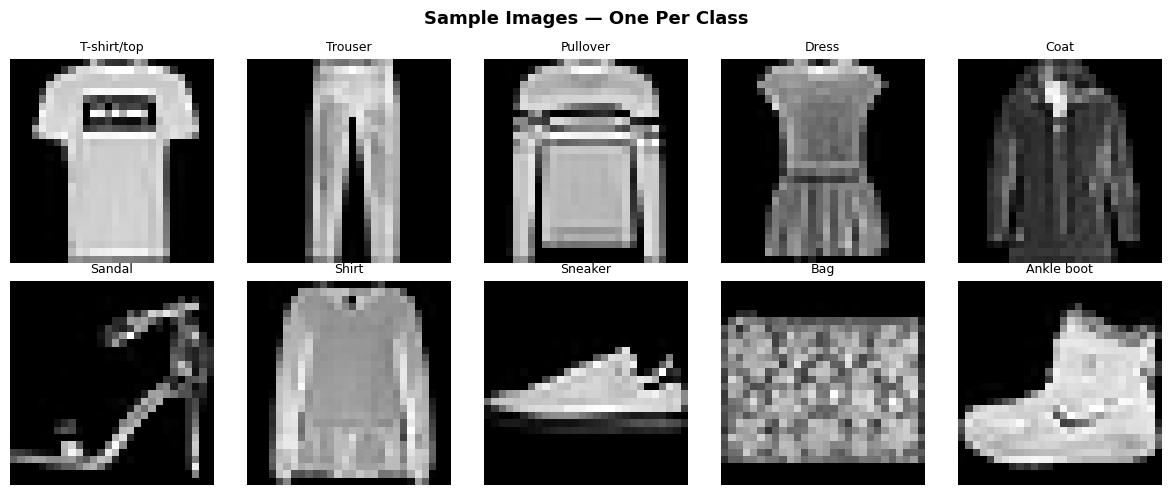

In [4]:
#Show sample images from each class

plt.figure(figsize=(12, 5))
for i in range(10):
    # Pick one sample from each class
    idx = np.where(y_train == i)[0][0]
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[idx], cmap="gray")
    plt.title(class_names[i], fontsize=9)
    plt.axis("off")
plt.suptitle("Sample Images — One Per Class", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("sample_images.png", dpi=120)
plt.show()

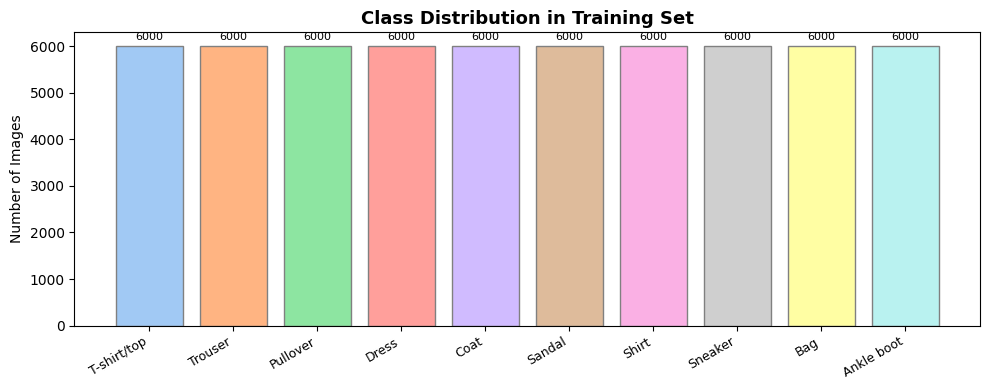

In [5]:
#Distribution of classes in training set

plt.figure(figsize=(10, 4))
counts = np.bincount(y_train)
colors = sns.color_palette("pastel", 10)
bars = plt.bar(class_names, counts, color=colors, edgecolor="gray")
plt.xticks(rotation=30, ha="right", fontsize=9)
plt.ylabel("Number of Images")
plt.title("Class Distribution in Training Set", fontsize=13, fontweight="bold")
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 100,
             str(count), ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=120)
plt.show()

#Preprocessing

In [6]:
#Normalize pixel values from [0, 255] → [0.0, 1.0]

X_train = X_train / 255.0
X_test  = X_test  / 255.0

In [7]:
#Flatten 28×28 images into 784-dimensional vectors
#(FCNN needs 1-D input, not 2-D images)

X_train_flat = X_train.reshape(-1, 784)   # shape: (60000, 784)
X_test_flat  = X_test.reshape(-1, 784)    # shape: (10000, 784)

In [8]:
#One-Hot Encode the labels
#e.g. class 3 → [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]

y_train_ohe = to_categorical(y_train, num_classes=10)
y_test_ohe  = to_categorical(y_test,  num_classes=10)

print("Flattened training shape :", X_train_flat.shape)
print("One-hot label shape      :", y_train_ohe.shape)

Flattened training shape : (60000, 784)
One-hot label shape      : (60000, 10)


#Build the FCNN Model

In [9]:
#  Architecture:
#   Input  →  784 neurons  (one per pixel)
#   Dense  →  256 neurons  (ReLU)  + BatchNorm + Dropout
#   Dense  →  128 neurons  (ReLU)  + BatchNorm + Dropout
#   Dense  →   64 neurons  (ReLU)
#   Output →   10 neurons  (Softmax — one per class)

In [10]:
model = keras.Sequential([
    # Input layer
    layers.Input(shape=(784,)),

    # Hidden Layer 1
    layers.Dense(256, activation="relu"),
    layers.BatchNormalization(),        # stabilises & speeds up training
    layers.Dropout(0.3),               # randomly drops 30% neurons → less overfitting

    # Hidden Layer 2
    layers.Dense(128, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    # Hidden Layer 3
    layers.Dense(64, activation="relu"),

    # Output Layer — 10 classes, Softmax gives probabilities
    layers.Dense(10, activation="softmax")
], name="Fashion_FCNN")

model.summary()

Model: "Fashion_FCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 244,298 (954.29 KB)

 Trainable params: 243,530 (951.29 KB)

 Non-trainable params: 768 (3.00 KB)

#Compile the Model

In [11]:
model.compile(
    optimizer="sgd",                        # Stochastic Gradient Descent (as required)
    loss="categorical_crossentropy",        # Multi-class log loss
    metrics=["accuracy"]
)

#Train the Model

In [12]:
#validation_split=0.1 means 10% of training data is used
#to monitor performance on unseen data each epoch

history = model.fit(
    X_train_flat, y_train_ohe,
    epochs=30,
    batch_size=64,
    validation_split=0.1,       # 10% held out for validation
    verbose=1
)

Epoch 1/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7294 - loss: 0.7884 - val_accuracy: 0.8182 - val_loss: 0.4871
Epoch 2/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8079 - loss: 0.5412 - val_accuracy: 0.8458 - val_loss: 0.4276
Epoch 3/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8225 - loss: 0.4923 - val_accuracy: 0.8533 - val_loss: 0.4011
Epoch 4/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8347 - loss: 0.4610 - val_accuracy: 0.8608 - val_loss: 0.3762
Epoch 5/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8431 - loss: 0.4337 - val_accuracy: 0.8650 - val_loss: 0.3696
Epoch 6/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8506 - loss: 0.4166 - val_accuracy: 0.8635 - val_loss: 0.3697
Epoch 7/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8544 - loss: 0.4025 - val_accuracy: 0.8688 - val_loss: 0.3551
Epoch 8/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8576 - loss: 0.3939 - val_accuracy: 0.

#Evaluate on Test Set

In [13]:
test_loss, test_accuracy = model.evaluate(X_test_flat, y_test_ohe, verbose=0)
print(f"\nTest Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy * 100:.2f}%")


Test Loss     : 0.3275
Test Accuracy : 88.55%


#Plot Training History

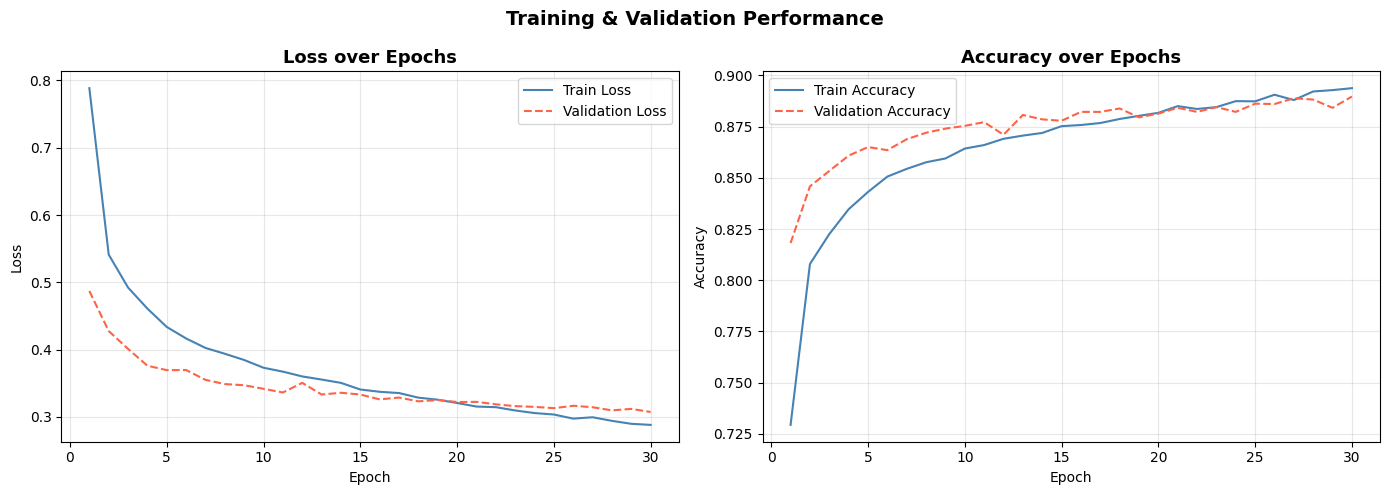

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, len(history.history["loss"]) + 1)

# --- Loss ---
ax1.plot(epochs_range, history.history["loss"],     label="Train Loss",      color="steelblue")
ax1.plot(epochs_range, history.history["val_loss"], label="Validation Loss", color="tomato", linestyle="--")
ax1.set_title("Loss over Epochs", fontsize=13, fontweight="bold")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- Accuracy ---
ax2.plot(epochs_range, history.history["accuracy"],     label="Train Accuracy",      color="steelblue")
ax2.plot(epochs_range, history.history["val_accuracy"], label="Validation Accuracy", color="tomato", linestyle="--")
ax2.set_title("Accuracy over Epochs", fontsize=13, fontweight="bold")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle("Training & Validation Performance", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("training_history.png", dpi=120)
plt.show()

#Confusion Matrix

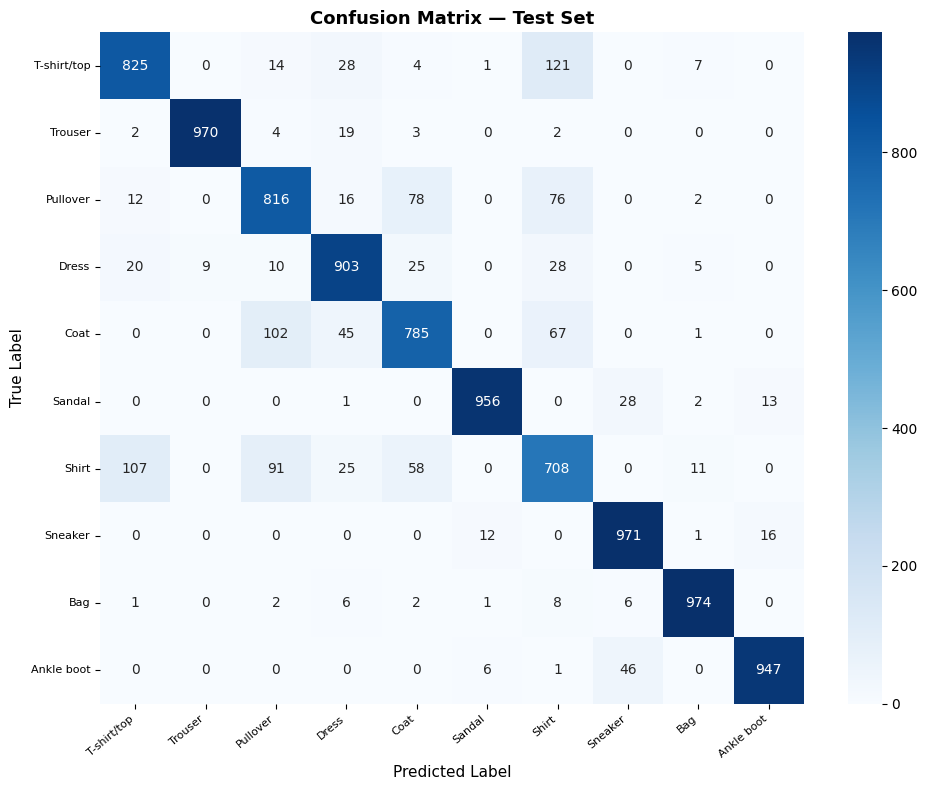

In [16]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred_probs = model.predict(X_test_flat, verbose=0)
y_pred       = np.argmax(y_pred_probs, axis=1)   # predicted class index

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label", fontsize=11)
plt.ylabel("True Label",      fontsize=11)
plt.title("Confusion Matrix — Test Set", fontsize=13, fontweight="bold")
plt.xticks(rotation=40, ha="right", fontsize=8)
plt.yticks(rotation=0,  fontsize=8)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=120)
plt.show()

In [17]:
# Detailed per-class metrics

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))


Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.85      0.82      0.84      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.79      0.82      0.80      1000
       Dress       0.87      0.90      0.88      1000
        Coat       0.82      0.79      0.80      1000
      Sandal       0.98      0.96      0.97      1000
       Shirt       0.70      0.71      0.70      1000
     Sneaker       0.92      0.97      0.95      1000
         Bag       0.97      0.97      0.97      1000
  Ankle boot       0.97      0.95      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



#Visualise Some Predictions

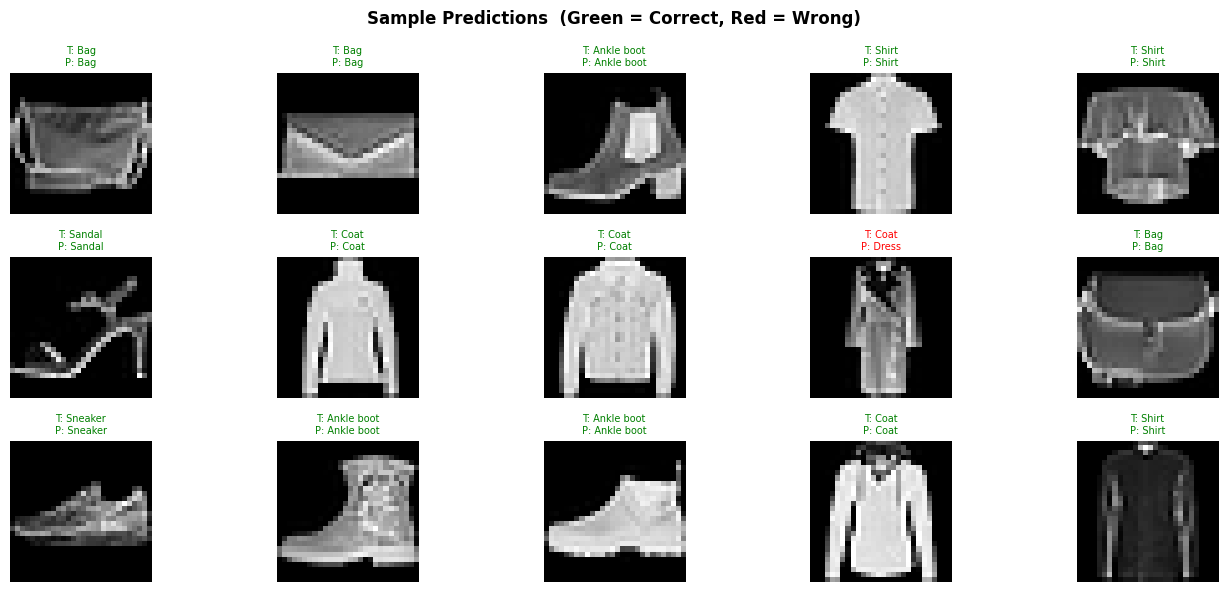

In [18]:
plt.figure(figsize=(14, 6))
sample_indices = np.random.choice(len(X_test), 15, replace=False)

for i, idx in enumerate(sample_indices):
    ax = plt.subplot(3, 5, i + 1)
    plt.imshow(X_test[idx], cmap="gray")

    true_label = class_names[y_test[idx]]
    pred_label = class_names[y_pred[idx]]
    correct    = y_test[idx] == y_pred[idx]

    ax.set_title(f"T: {true_label}\nP: {pred_label}",
                 color="green" if correct else "red", fontsize=7)
    plt.axis("off")

plt.suptitle("Sample Predictions  (Green = Correct, Red = Wrong)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("predictions.png", dpi=120)
plt.show()